# Portfolio Risk and Return Analysis
Midterm Project: Exploratory Data Analysis

**Research Question:** How do portfolios built for Conservative, Moderate, and Aggressive investors compare in returns, risk, and performance from 2019–2024?

- Data Source: Alpha Vantage API

Premises:

Conservative | BND, TLT, GLD, VYM, JNJ | Bonds, gold, dividend stocks — low risk

Moderate | SPY, QQQ, AAPL, MSFT, VTI | Broad market ETFs + big tech — balanced

Aggressive | TSLA, NVDA, ARKK, AMZN, META | High-growth tech — high risk, high reward

In [ ]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
sns.set_theme()
print('Libraries loaded.')

Libraries loaded.


In [ ]:
#Three portfolios: one per investor risk profile
portfolios = {
    'Conservative': ['BND', 'TLT', 'GLD', 'VYM', 'JNJ'],
    'Moderate':     ['SPY', 'QQQ', 'AAPL', 'MSFT', 'VTI'],
    'Aggressive':   ['TSLA', 'NVDA', 'ARKK', 'AMZN', 'META']}

In [ ]:
#Colors used in every chart. One per profile.
profile_colors = {
    'Conservative': '#2196F3',
    'Moderate':     '#4CAF50',
    'Aggressive':   '#F44336'}

In [ ]:
#To organize, I moved all tickers into one list
all_tickers = []
for profile, tickers in portfolios.items():
    for ticker in tickers:
        all_tickers.append(ticker)

In [ ]:
print('Profiles:', list(portfolios.keys()))
print('Total tickers:', len(all_tickers))
print(all_tickers)

Profiles: ['Conservative', 'Moderate', 'Aggressive']
Total tickers: 15
['BND', 'TLT', 'GLD', 'VYM', 'JNJ', 'SPY', 'QQQ', 'AAPL', 'MSFT', 'VTI', 'TSLA', 'NVDA', 'ARKK', 'AMZN', 'META']


In [ ]:
tickers_list  = []
profiles_list = []
dates_list    = []
prices_list   = []

In [ ]:
for profile, tickers in portfolios.items():
    for ticker in tickers:
        print(f'Fetching {ticker} ({profile})...', end=' ')

        #Monthly prices from 2020 to 2024
        stock = yf.download(ticker, start='2020-01-01', end='2024-12-31',
                            interval='1mo', progress=False)

        if stock.empty:
            print('no data returned')
            continue

        for date, row in stock.iterrows():
            tickers_list.append(ticker)
            profiles_list.append(profile)
            dates_list.append(date)
            prices_list.append(round(float(row['Close']), 2))

        print('done')

print(f'\nTotal rows collected: {len(tickers_list)}')

Fetching BND (Conservative)... done
Fetching TLT (Conservative)... done
Fetching GLD (Conservative)... done
Fetching VYM (Conservative)... done
Fetching JNJ (Conservative)... 

/tmp/ipykernel_9408/2433786311.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock = yf.download(ticker, start='2020-01-01', end='2024-12-31',
/tmp/ipykernel_9408/2433786311.py:17: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  prices_list.append(round(float(row['Close']), 2))
/tmp/ipykernel_9408/2433786311.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock = yf.download(ticker, start='2020-01-01', end='2024-12-31',
/tmp/ipykernel_9408/2433786311.py:17: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  prices_list.append(round(float(row['Close']), 2))
/tmp/ipykernel_9408/2433786311.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock = yf.download(ticker, start='2020-01-01', end

done
Fetching SPY (Moderate)... done
Fetching QQQ (Moderate)... done
Fetching AAPL (Moderate)... done
Fetching MSFT (Moderate)... done
Fetching VTI (Moderate)... 

/tmp/ipykernel_9408/2433786311.py:17: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  prices_list.append(round(float(row['Close']), 2))
/tmp/ipykernel_9408/2433786311.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock = yf.download(ticker, start='2020-01-01', end='2024-12-31',
/tmp/ipykernel_9408/2433786311.py:17: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  prices_list.append(round(float(row['Close']), 2))
/tmp/ipykernel_9408/2433786311.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock = yf.download(ticker, start='2020-01-01', end='2024-12-31',
/tmp/ipykernel_9408/2433786311.py:17: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc

done
Fetching TSLA (Aggressive)... done
Fetching NVDA (Aggressive)... done
Fetching ARKK (Aggressive)... done
Fetching AMZN (Aggressive)... done
Fetching META (Aggressive)... done

Total rows collected: 1800


/tmp/ipykernel_9408/2433786311.py:17: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  prices_list.append(round(float(row['Close']), 2))


In [ ]:
df = pd.DataFrame({
    'Ticker':       tickers_list,
    'Risk Profile': profiles_list,
    'Date':         dates_list,
    'Price':        prices_list})

In [ ]:
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

In [ ]:
print(f'DataFrame shape: {df.shape}')
print(f'\nData types:')
print(df.dtypes)
df.head(10)

DataFrame shape: (900, 4)

Data types:
Ticker                  object
Risk Profile            object
Date            datetime64[ns]
Price                  float64
dtype: object


,Ticker,Risk Profile,Date,Price
0,BND,Conservative,2020-01-01,71.25
1,QQQ,Moderate,2020-01-01,211.39
2,VTI,Moderate,2020-01-01,149.72
3,AMZN,Aggressive,2020-01-01,100.44
4,GLD,Conservative,2020-01-01,149.33
5,SPY,Moderate,2020-01-01,294.02
6,TSLA,Aggressive,2020-01-01,43.37
7,AAPL,Moderate,2020-01-01,74.61
8,ARKK,Aggressive,2020-01-01,50.15
9,VYM,Conservative,2020-01-01,75.66


In [ ]:
print('General Info')
df.info()

General Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 900 entries, 0 to 899
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Ticker        900 non-null    object        
 1   Risk Profile  900 non-null    object        
 2   Date          900 non-null    datetime64[ns]
 3   Price         900 non-null    float64       
dtypes: datetime64[ns](1), float64(1), object(2)
memory usage: 28.3+ KB


In [ ]:
print('First 5 rows')
print(df.head())

First 5 rows
  Ticker  Risk Profile       Date   Price
0    BND  Conservative 2020-01-01   71.25
1    QQQ      Moderate 2020-01-01  211.39
2    VTI      Moderate 2020-01-01  149.72
3   AMZN    Aggressive 2020-01-01  100.44
4    GLD  Conservative 2020-01-01  149.33


In [ ]:
print('Summary statistics')
print(df.describe())

Summary statistics
                                Date       Price
count                            900  900.000000
mean   2022-06-16 15:12:00.000000256  183.654233
min              2020-01-01 00:00:00    5.880000
25%              2021-03-24 06:00:00   93.990000
50%              2022-06-16 00:00:00  157.525000
75%              2023-09-08 12:00:00  245.327500
max              2024-12-01 00:00:00  591.940000
std                              NaN  119.646045


In [ ]:
print('How many months per ticker?')
print(df['Ticker'].value_counts())

How many months per ticker?
Ticker
BND     60
QQQ     60
VTI     60
AMZN    60
GLD     60
SPY     60
TSLA    60
AAPL    60
ARKK    60
VYM     60
MSFT    60
META    60
TLT     60
JNJ     60
NVDA    60
Name: count, dtype: int64


In [ ]:
print('How many tickers per profile?')
print(df['Risk Profile'].value_counts())

How many tickers per profile?
Risk Profile
Conservative    300
Moderate        300
Aggressive      300
Name: count, dtype: int64


#For each ticker, I calculate:
1. Total return: how much the price grew from start to end
2. Average price: the typical price over the period
3. Risk (std): how much the price bounced around — higher = more risky
4. Performance label: High / Medium / Low using if/elif/else

In [ ]:
#"Checkpoint" (because when using API I was having issues with missing tickers)
print(df['Ticker'].value_counts())
print('Total rows:', len(df))

Ticker
BND     60
QQQ     60
VTI     60
AMZN    60
GLD     60
SPY     60
TSLA    60
AAPL    60
ARKK    60
VYM     60
MSFT    60
META    60
TLT     60
JNJ     60
NVDA    60
Name: count, dtype: int64
Total rows: 900


In [ ]:
#For each ticker, I looked for the first and last price in the dataset
tickers_summary  = []
profiles_summary = []
start_prices     = []
end_prices       = []

for profile, tickers in portfolios.items():
    for ticker in tickers:
        ticker_data = df.loc[df['Ticker'] == ticker]
        start_prices.append(round(ticker_data['Price'].iloc[0], 2))
        end_prices.append(round(ticker_data['Price'].iloc[-1], 2))
        tickers_summary.append(ticker)
        profiles_summary.append(profile)

print('Done! First few start prices:', start_prices[:3])
print('First few end prices:', end_prices[:3])

Done! First few start prices: [np.float64(71.25), np.float64(122.06), np.float64(149.33)]
First few end prices: [np.float64(68.3), np.float64(82.41), np.float64(242.13)]


In [ ]:
#Calculating total return; how much the price grew from start to end (in %)?

total_returns = []

for i in range(len(tickers_summary)):
    total_return = (end_prices[i] - start_prices[i]) / start_prices[i] * 100
    total_returns.append(round(total_return, 2))

print('Total returns:', total_returns)

Total returns: [np.float64(-4.14), np.float64(-32.48), np.float64(62.14), np.float64(62.15), np.float64(11.6), np.float64(95.82), np.float64(140.23), np.float64(233.82), np.float64(158.87), np.float64(90.62), np.float64(831.15), np.float64(2182.99), np.float64(13.2), np.float64(118.43), np.float64(190.86)]


In [ ]:
#Calculating average price and std (volatility) for each ticker

avg_prices = []
std_prices = []

for profile, tickers in portfolios.items():
    for ticker in tickers:
        ticker_data = df.loc[df['Ticker'] == ticker]
        avg_prices.append(round(ticker_data['Price'].mean(), 2))
        std_prices.append(round(ticker_data['Price'].std(), 2))

print('Avg prices:', avg_prices[:3])
print('Std prices:', std_prices[:3])

Avg prices: [np.float64(69.49), np.float64(107.05), np.float64(181.1)]
Std prices: [3.99, 20.94, 24.73]


In [ ]:
#Assigning performance based on total return

performance = []

for total_return in total_returns:
    if total_return >= 200:
        label = 'High Performer'
    elif total_return >= 50:
        label = 'Medium Performer'
    else:
        label = 'Low Performer'
    performance.append(label)

print('Performance labels:', performance)

Performance labels: ['Low Performer', 'Low Performer', 'Medium Performer', 'Medium Performer', 'Low Performer', 'Medium Performer', 'Medium Performer', 'High Performer', 'Medium Performer', 'Medium Performer', 'High Performer', 'High Performer', 'Low Performer', 'Medium Performer', 'Medium Performer']


In [ ]:
summary = pd.DataFrame({
    'Ticker':           tickers_summary,
    'Risk Profile':     profiles_summary,
    'Start Price ($)':  start_prices,
    'End Price ($)':    end_prices,
    'Total Return (%)': total_returns,
    'Avg Price ($)':    avg_prices,
    'Volatility (std)': std_prices,
    'Performance':      performance})

summary = summary.sort_values('Total Return (%)', ascending=False).reset_index(drop=True)
summary

,Ticker,Risk Profile,Start Price ($),End Price ($),Total Return (%),Avg Price ($),Volatility (std),Performance
0,NVDA,Aggressive,5.88,134.24,2182.99,39.14,38.55,High Performer
1,TSLA,Aggressive,43.37,403.84,831.15,218.46,83.48,High Performer
2,AAPL,Moderate,74.61,249.06,233.82,152.77,42.85,High Performer
3,META,Aggressive,200.34,582.70,190.86,299.34,124.02,Medium Performer
4,MSFT,Moderate,161.26,417.46,158.87,287.47,80.30,Medium Performer
5,QQQ,Moderate,211.39,507.83,140.23,339.72,79.39,Medium Performer
6,AMZN,Aggressive,100.44,219.39,118.43,146.87,31.60,Medium Performer
7,SPY,Moderate,294.02,575.76,95.82,405.81,81.93,Medium Performer
8,VTI,Moderate,149.72,285.40,90.62,204.60,39.50,Medium Performer
9,VYM,Conservative,75.66,122.68,62.15,93.97,16.34,Medium Performer


In [ ]:
#Average return and volatility per risk profile
profile_stats = summary.groupby('Risk Profile')[['Total Return (%)', 'Volatility (std)']].mean().round(2)
print(profile_stats)

              Total Return (%)  Volatility (std)
Risk Profile                                    
Aggressive              667.33             61.81
Conservative             19.85             15.64
Moderate                143.87             64.79


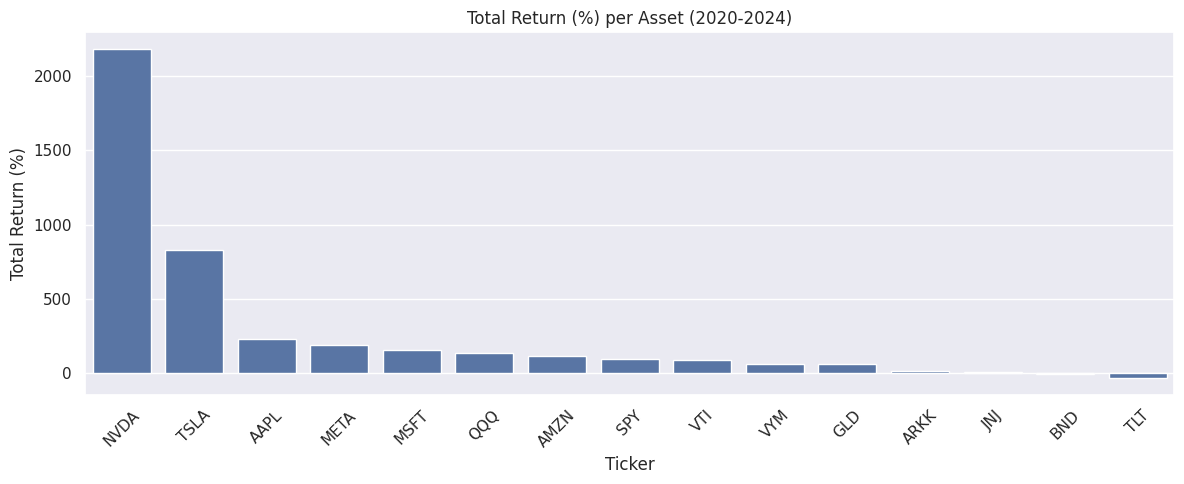

In [ ]:
#Total return per asset
plt.figure(figsize=(12, 5))
sns.barplot(data=summary, x='Ticker', y='Total Return (%)')
plt.title('Total Return (%) per Asset (2020-2024)')
plt.xlabel('Ticker')
plt.ylabel('Total Return (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

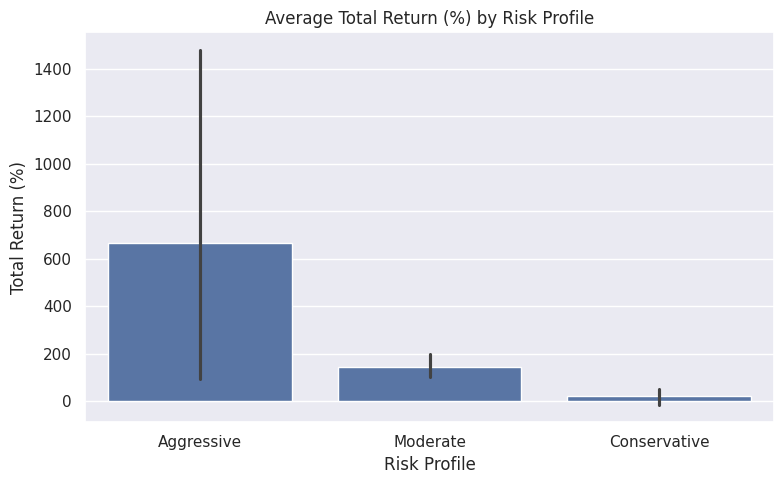

In [ ]:
#Avarage return by profile
plt.figure(figsize=(8, 5))
sns.barplot(data=summary, x='Risk Profile', y='Total Return (%)')
plt.title('Average Total Return (%) by Risk Profile')
plt.xlabel('Risk Profile')
plt.ylabel('Total Return (%)')
plt.tight_layout()
plt.show()

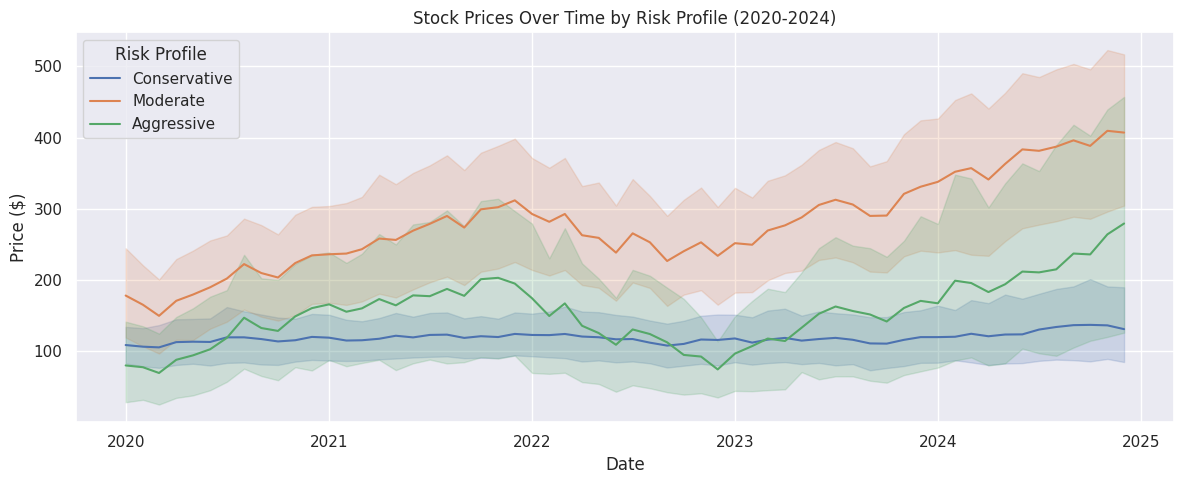

In [ ]:
#Price over time
plt.figure(figsize=(12, 5))
sns.lineplot(data=df, x='Date', y='Price', hue='Risk Profile')
plt.title('Stock Prices Over Time by Risk Profile (2020-2024)')
plt.xlabel('Date')
plt.ylabel('Price ($)')
plt.tight_layout()
plt.show()

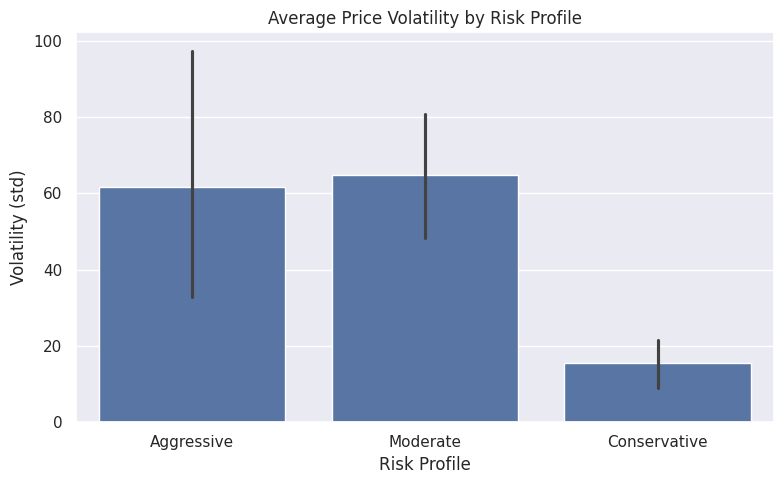

In [ ]:
#Volatility by profile
plt.figure(figsize=(8, 5))
sns.barplot(data=summary, x='Risk Profile', y='Volatility (std)')
plt.title('Average Price Volatility by Risk Profile')
plt.xlabel('Risk Profile')
plt.ylabel('Volatility (std)')
plt.tight_layout()
plt.show()

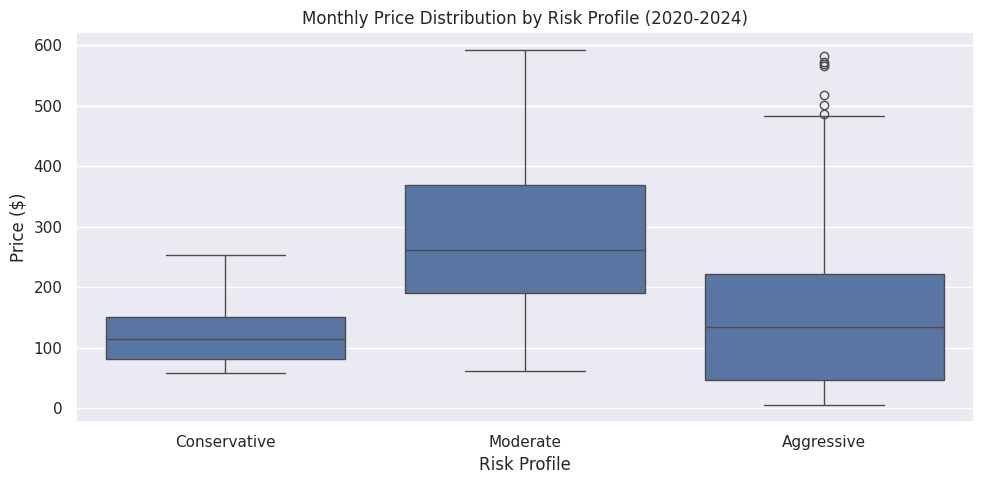

In [ ]:
#Price distribution box plot
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='Risk Profile', y='Price')
plt.title('Monthly Price Distribution by Risk Profile (2020-2024)')
plt.xlabel('Risk Profile')
plt.ylabel('Price ($)')
plt.tight_layout()
plt.show()

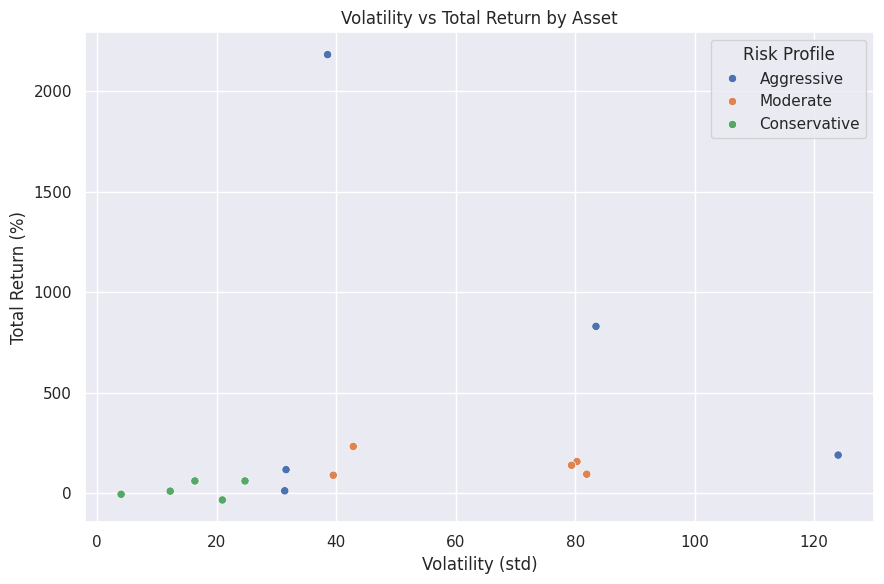

In [ ]:
#Volatility vs return scatter
plt.figure(figsize=(9, 6))
sns.scatterplot(data=summary, x='Volatility (std)', y='Total Return (%)', hue='Risk Profile')
plt.title('Volatility vs Total Return by Asset')
plt.xlabel('Volatility (std)')
plt.ylabel('Total Return (%)')
plt.tight_layout()
plt.show()

In [ ]:
#Top and Bottom performers
print('Top 3 assets by total return:')
print(summary[['Ticker', 'Risk Profile', 'Total Return (%)']].nlargest(3, 'Total Return (%)'))

print('\nBottom 3 assets by total return:')
print(summary[['Ticker', 'Risk Profile', 'Total Return (%)']].nsmallest(3, 'Total Return (%)'))

Top 3 assets by total return:
  Ticker Risk Profile  Total Return (%)
0   NVDA   Aggressive           2182.99
1   TSLA   Aggressive            831.15
2   AAPL     Moderate            233.82

Bottom 3 assets by total return:
   Ticker  Risk Profile  Total Return (%)
14    TLT  Conservative            -32.48
13    BND  Conservative             -4.14
12    JNJ  Conservative             11.60


# Stock Price Analysis: Which Companies Performed Best from 2020 to 2024?

**Research Question:** How do the stock prices of six major tech companies compare in terms of price growth, total return, and performance category from 2020 to 2024?

**Data Source:** yfinance library: monthly closing prices for AAPL, MSFT, TSLA, AMZN, GOOGL, and NVDA.

In [ ]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
sns.set_theme()
print('Libraries loaded.')

Libraries loaded.


In [ ]:
#The 6 companies we are analyzing
stocks = ['AAPL', 'MSFT', 'TSLA', 'AMZN', 'GOOGL', 'NVDA']

In [ ]:
#Full company names stored in a dictionary
company_names = {
    'AAPL':  'Apple',
    'MSFT':  'Microsoft',
    'TSLA':  'Tesla',
    'AMZN':  'Amazon',
    'GOOGL': 'Google',
    'NVDA':  'Nvidia'}

In [ ]:
print('Stocks:', stocks)

Stocks: ['AAPL', 'MSFT', 'TSLA', 'AMZN', 'GOOGL', 'NVDA']


In [ ]:
tickers_list  = []
companies_list = []
dates_list    = []
prices_list   = []

In [ ]:
for ticker in stocks:
    print(f'Fetching {ticker}...', end=' ')

    stock = yf.download(ticker, start='2020-01-01', end='2024-12-31',
                        interval='1mo', progress=False)

    if stock.empty:
        print('no data returned')
        continue

    for date, row in stock.iterrows():
        tickers_list.append(ticker)
        companies_list.append(company_names[ticker])
        dates_list.append(date)
        prices_list.append(round(float(row['Close']), 2))

    print('done')

print(f'\nTotal rows collected: {len(tickers_list)}')

Fetching AAPL... done
Fetching MSFT... done
Fetching TSLA... done
Fetching AMZN... done
Fetching GOOGL... 

/tmp/ipykernel_3546/783092665.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock = yf.download(ticker, start='2020-01-01', end='2024-12-31',
/tmp/ipykernel_3546/783092665.py:15: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  prices_list.append(round(float(row['Close']), 2))
/tmp/ipykernel_3546/783092665.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock = yf.download(ticker, start='2020-01-01', end='2024-12-31',
/tmp/ipykernel_3546/783092665.py:15: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  prices_list.append(round(float(row['Close']), 2))
/tmp/ipykernel_3546/783092665.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock = yf.download(ticker, start='2020-01-01', end='202

done
Fetching NVDA... done

Total rows collected: 360


/tmp/ipykernel_3546/783092665.py:15: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  prices_list.append(round(float(row['Close']), 2))
/tmp/ipykernel_3546/783092665.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock = yf.download(ticker, start='2020-01-01', end='2024-12-31',
/tmp/ipykernel_3546/783092665.py:15: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  prices_list.append(round(float(row['Close']), 2))


In [ ]:
#To organize, I moved all tickers into one list
df = pd.DataFrame({
    'Ticker':  tickers_list,
    'Company': companies_list,
    'Date':    dates_list,
    'Price':   prices_list})

In [ ]:
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

print('Shape:', df.shape)
df.head()

Shape: (360, 4)


,Ticker,Company,Date,Price
0,AAPL,Apple,2020-01-01,74.61
1,AMZN,Amazon,2020-01-01,100.44
2,MSFT,Microsoft,2020-01-01,161.26
3,GOOGL,Google,2020-01-01,71.05
4,NVDA,Nvidia,2020-01-01,5.88


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 360 entries, 0 to 359
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   Ticker   360 non-null    object        
 1   Company  360 non-null    object        
 2   Date     360 non-null    datetime64[ns]
 3   Price    360 non-null    float64       
dtypes: datetime64[ns](1), float64(1), object(2)
memory usage: 11.4+ KB


In [ ]:
print(df.describe())

                      Date       Price
count                  360  360.000000
mean   2022-06-16 15:12:00  160.511750
min    2020-01-01 00:00:00    5.880000
25%    2021-03-24 06:00:00  100.397500
50%    2022-06-16 00:00:00  151.875000
75%    2023-09-08 12:00:00  213.225000
max    2024-12-01 00:00:00  440.990000
std                    NaN   95.628719


In [ ]:
print(df['Ticker'].value_counts())

Ticker
AAPL     60
AMZN     60
MSFT     60
GOOGL    60
NVDA     60
TSLA     60
Name: count, dtype: int64


In [ ]:
#For each stock, find the first and last price
tickers_summary  = []
companies_summary = []
start_prices     = []
end_prices       = []

for ticker in stocks:
    ticker_data = df.loc[df['Ticker'] == ticker]
    tickers_summary.append(ticker)
    companies_summary.append(company_names[ticker])
    start_prices.append(round(ticker_data['Price'].iloc[0], 2))
    end_prices.append(round(ticker_data['Price'].iloc[-1], 2))

print('Start prices:', start_prices)
print('End prices:', end_prices)

Start prices: [np.float64(74.61), np.float64(161.26), np.float64(43.37), np.float64(100.44), np.float64(71.05), np.float64(5.88)]
End prices: [np.float64(249.06), np.float64(417.46), np.float64(403.84), np.float64(219.39), np.float64(188.21), np.float64(134.24)]


In [ ]:
#Total return; How much the price grew from start to end (in %)?

total_returns = []

for i in range(len(tickers_summary)):
    total_return = (end_prices[i] - start_prices[i]) / start_prices[i] * 100
    total_returns.append(round(total_return, 2))

print('Total returns:', total_returns)

Total returns: [np.float64(233.82), np.float64(158.87), np.float64(831.15), np.float64(118.43), np.float64(164.9), np.float64(2182.99)]


In [ ]:
#Average price and std for each stock
avg_prices = []
std_prices = []

for ticker in stocks:
    ticker_data = df.loc[df['Ticker'] == ticker]
    avg_prices.append(round(ticker_data['Price'].mean(), 2))
    std_prices.append(round(ticker_data['Price'].std(), 2))

print('Avg prices:', avg_prices)
print('Volatility:', std_prices)

Avg prices: [np.float64(152.77), np.float64(287.47), np.float64(218.46), np.float64(146.87), np.float64(118.37), np.float64(39.14)]
Volatility: [42.85, 80.3, 83.48, 31.6, 32.59, 38.55]


In [ ]:
#if/elif/else used to assign performance
performance = []

for total_return in total_returns:
    if total_return >= 300:
        label = 'High Performer'
    elif total_return >= 100:
        label = 'Medium Performer'
    else:
        label = 'Low Performer'
    performance.append(label)

print('Labels:', performance)

Labels: ['Medium Performer', 'Medium Performer', 'High Performer', 'Medium Performer', 'Medium Performer', 'High Performer']


In [ ]:
summary = pd.DataFrame({
    'Ticker':           tickers_summary,
    'Company':          companies_summary,
    'Start Price ($)':  start_prices,
    'End Price ($)':    end_prices,
    'Total Return (%)': total_returns,
    'Avg Price ($)':    avg_prices,
    'Volatility (std)': std_prices,
    'Performance':      performance})
summary = summary.sort_values('Total Return (%)', ascending=False).reset_index(drop=True)
summary

,Ticker,Company,Start Price ($),End Price ($),Total Return (%),Avg Price ($),Volatility (std),Performance
0,NVDA,Nvidia,5.88,134.24,2182.99,39.14,38.55,High Performer
1,TSLA,Tesla,43.37,403.84,831.15,218.46,83.48,High Performer
2,AAPL,Apple,74.61,249.06,233.82,152.77,42.85,Medium Performer
3,GOOGL,Google,71.05,188.21,164.90,118.37,32.59,Medium Performer
4,MSFT,Microsoft,161.26,417.46,158.87,287.47,80.30,Medium Performer
5,AMZN,Amazon,100.44,219.39,118.43,146.87,31.60,Medium Performer


In [ ]:
print('Average stats by performance category')
print(summary.groupby('Performance')[['Total Return (%)', 'Avg Price ($)']].mean().round(2))

Average stats by performance category
                  Total Return (%)  Avg Price ($)
Performance                                      
High Performer             1507.07         128.80
Medium Performer            169.00         176.37


In [ ]:
#Top and bottom performers
print('Top 3 by total return:')
print(summary[['Company', 'Total Return (%)']].nlargest(3, 'Total Return (%)'))

print('Bottom 3 by total return:')
print(summary[['Company', 'Total Return (%)']].nsmallest(3, 'Total Return (%)'))

Top 3 by total return:
  Company  Total Return (%)
0  Nvidia           2182.99
1   Tesla            831.15
2   Apple            233.82
Bottom 3 by total return:
     Company  Total Return (%)
5     Amazon            118.43
4  Microsoft            158.87
3     Google            164.90


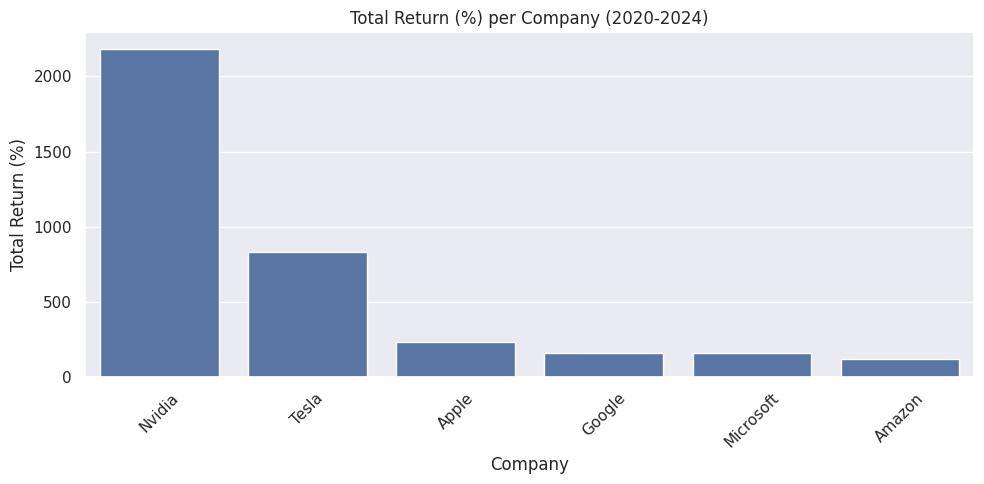

In [ ]:
#Total return
plt.figure(figsize=(10, 5))
sns.barplot(data=summary, x='Company', y='Total Return (%)')
plt.title('Total Return (%) per Company (2020-2024)')
plt.xlabel('Company')
plt.ylabel('Total Return (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

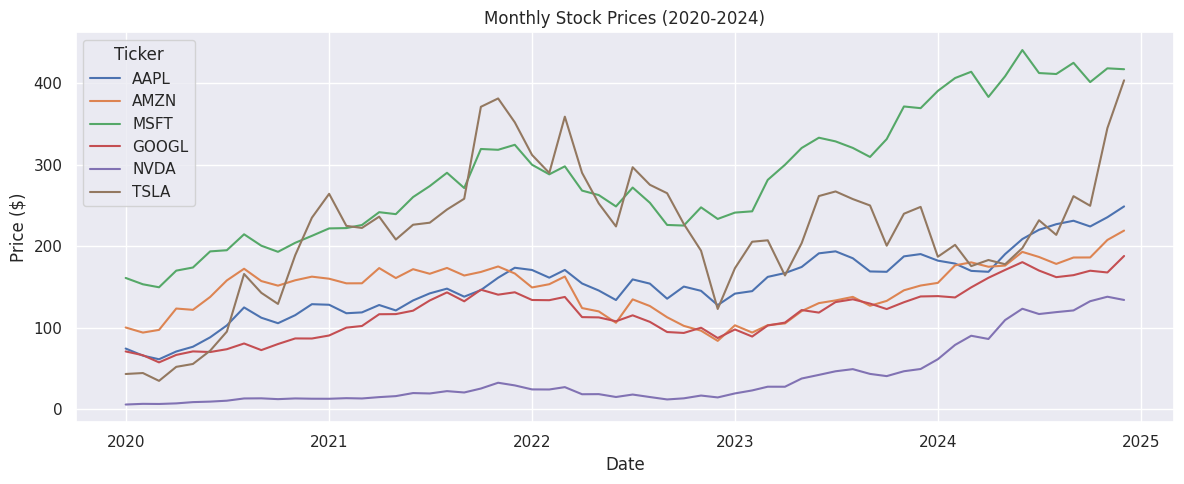

In [ ]:
#Price over time
plt.figure(figsize=(12, 5))
sns.lineplot(data=df, x='Date', y='Price', hue='Ticker')
plt.title('Monthly Stock Prices (2020-2024)')
plt.xlabel('Date')
plt.ylabel('Price ($)')
plt.tight_layout()
plt.show()

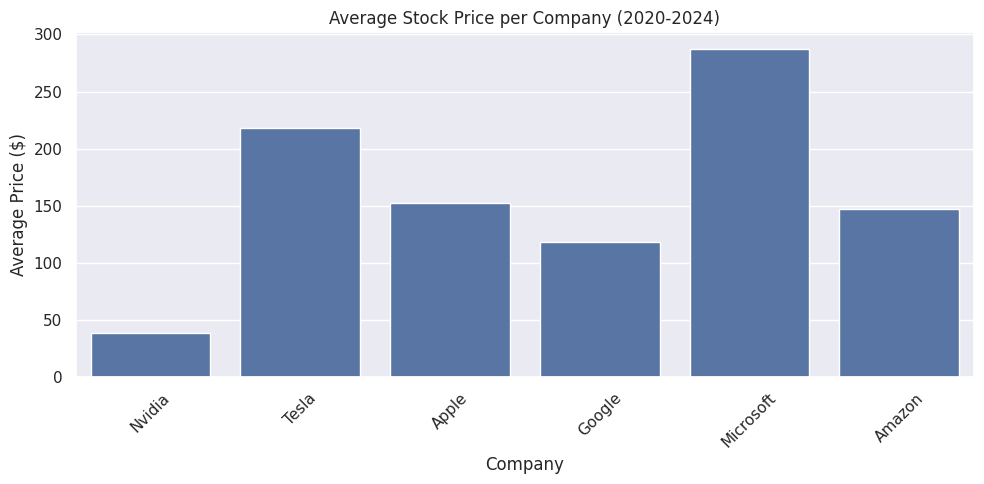

In [ ]:
#Avarage price bar chart
plt.figure(figsize=(10, 5))
sns.barplot(data=summary, x='Company', y='Avg Price ($)')
plt.title('Average Stock Price per Company (2020-2024)')
plt.xlabel('Company')
plt.ylabel('Average Price ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

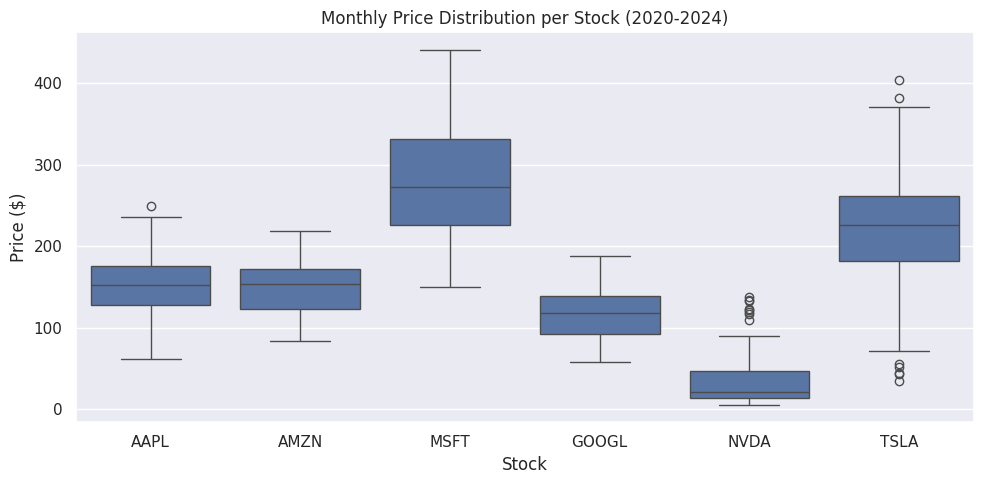

In [ ]:
#Price distribution
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='Ticker', y='Price')
plt.title('Monthly Price Distribution per Stock (2020-2024)')
plt.xlabel('Stock')
plt.ylabel('Price ($)')
plt.tight_layout()
plt.show()

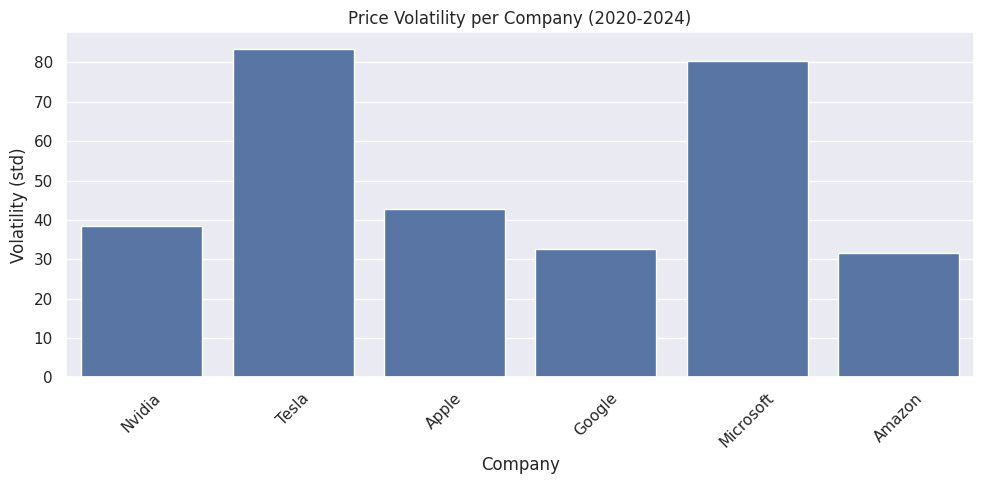

In [ ]:
#Volatility bar chart
plt.figure(figsize=(10, 5))
sns.barplot(data=summary, x='Company', y='Volatility (std)')
plt.title('Price Volatility per Company (2020-2024)')
plt.xlabel('Company')
plt.ylabel('Volatility (std)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

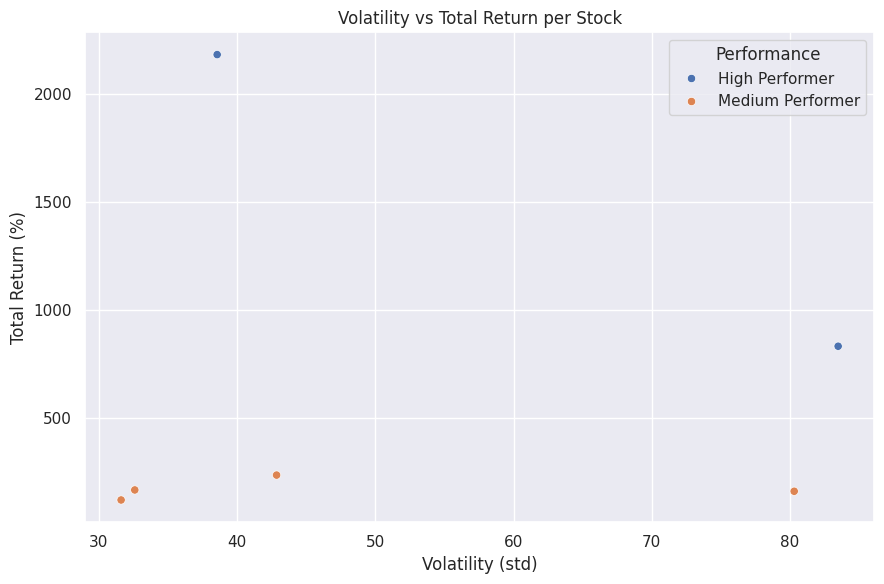

In [ ]:
#Volatility vs return
plt.figure(figsize=(9, 6))
sns.scatterplot(data=summary, x='Volatility (std)', y='Total Return (%)', hue='Performance')
plt.title('Volatility vs Total Return per Stock')
plt.xlabel('Volatility (std)')
plt.ylabel('Total Return (%)')
plt.tight_layout()
plt.show()

#Key Findings
1. **Nvidia (NVDA) was the top performer**: its price grew dramatically due to the AI boom of 2023-2024.

2. **Tesla (TSLA) was the most volatile**: its price swung the most, meaning highest risk.

3. **Microsoft and Apple were the most stable**: steady growth with less extreme price swings.

4. **Amazon and Google showed solid but moderate growth**: finishing as medium performers.

5. **Higher volatility did not always mean higher returns**: Tesla had high volatility but lower returns than Nvidia, showing that risk does not guarantee reward.

Write up Section

# Stock Market Exploratory Data Analysis: Portfolio Risk and Individual Stock Performance (2020–2024)

# Summary:

This project conducts an exploratory data analysis of stock market data to answer two related questions about financial performance from 2020 to 2024. The first analysis examines how three investor portfolios (Conservative, Moderate, and Aggressive) compare in terms of price growth, volatility, and overall performance. The second analysis looks closer into six individual major technology companies to determine which delivered the best returns and whether higher risk consistently translated into higher reward. I decided to include both analysis angles, as I realized early on that building an individual portfolio was proving to be a bit more challenging than I had expected given my Python skills.

Both analyses use the same data source, the same Python tools, and the same core methodology: pulling historical price data, organizing it into DataFrames, computing summary statistics, and producing visualizations that make the results eaier to interpret. Together, they offer a somewhat simple picture of how different types of investors would have acted during one of the most turbulent periods in recent stock market history, the COVID-19 pandemic crash of 2020, the Federal Reserve interest rate hikes of 2022, and the artificial intelligence boom of 2023-2024.

# Data Source:

I started by using an Alpha Vantage API, but because of the sheer number of iterations, it was running out of time very quickly. So, I turned to the yfinance Python library, which provides free access to historical stock market data from Yahoo Finance. No API key is required. Monthly adjusted closing prices were downloaded for all 21 assets (15 portfolio assets and 6 individual stocks) covering January 1, 2020 to December 31, 2024. This produced approx. 60 monthly observations per asset.
I chose monthly prices over daily prices to focus on longer-term trends and reduce noise from day-to-day fluctuations, while still capturing major market events clearly.

# Assets Analyzed:

Part 1 — Three Investor Portfolios (15 assets):
- Conservative: BND, TLT, GLD, VYM, JNJ
- Moderate: SPY, QQQ, AAPL, MSFT, VTI
- Aggressive: TSLA, NVDA, ARKK, AMZN, META

Part 2 — Six Individual Tech Companies:

1. Apple (AAPL)
2. Microsoft (MSFT)
3. Tesla (TSLA)
4. Amazon (AMZN)
5. Google (GOOGL)

# Methods:

Monthly closing prices were fetched for each ticker using a for loop and 'yf.download()', appended into lists, and combined into a pandas DataFrame. After converting the date column with 'pd.to_datetime()', data quality was checked 'using .info()', '.describe()', and '.value_counts()'.
Four metrics were then calculated for each asset. Total Return (%) was computed as '(end price - start price) / start price * 100'. Average Price was calculated using '.mean(). Volatility was measured as the standard deviation of monthly prices using '.std()', which a higher value means more price instability and therefore more risk. Performance Labels of High, Medium, or Low were assigned using an 'if/elif/else' statement based on total return.
Finally, assets were grouped using '.groupby()' to compare average statistics by profile or category, and '.nlargest()' and '.nsmallest()' identified the top and bottom performers.

# Visualizations:

Part 1 — Portfolio Analysis (6 charts):

1. Total Return per Asset (Bar Chart): Compares the growth of all 15 assets side by side, grouped by risk profile, showing which individual assets drove overall portfolio performance.
2. Average Total Return by Risk Profile (Bar Chart): Aggregates returns at the portfolio level, making it easy to compare "Conservative, Moderate, and Aggressive" investors next to each other.
3. Stock Prices Over Time by Risk Profile (Line Plot): Shows how the average price of each portfolio evolved month by month from 2020 to 2024, demonstrating major market events visually.
4. Average Price Volatility by Risk Profile (Bar Chart): Directly compares how much price instability each portfolio carried on average.
5. Monthly Price Distribution by Risk Profile (Box Plot): Shows the full spread of prices across the period for each profile, with wider boxes indicating greater variability.
6. Volatility vs. Total Return (Scatter Plot): The most analytical chart shows plots risk against reward for every asset, revealing whether taking on more volatility consistently led to better returns.

Part 2 — Individual Stock Analysis (6 charts):

The same six chart types were reproduced for the individual company analysis, allowing direct comparison of methodology and results across both parts of the project.

# Key Project Findings

Part 1 — Portfolio Analysis:

The Aggressive portfolio delivered the highest average returns. Assets like Nvidia and META drove significant growth, particularly from 2023 onwards. However, this came at the cost of substantially higher volatility, in which the Aggressive portfolio's price swings were far larger than those of the other two profiles.

The Conservative portfolio was the most stable but had the lowest returns. Assets like BND and TLT provided predictable, low-volatility performance. This is exactly what conservative investors seek: Protection of capital rather than growth. The tradeoff is that returns were modest, and during the 2022 rate hike cycle, even bond ETFs experienced price declines.

The Moderate portfolio struck the most consistent balance. Assets like SPY and VTI and large-cap tech stocks like AAPL and MSFT delivered meaningful returns with less extreme volatility than the Aggressive portfolio. For investors seeking growth without the full risk of individual high-growth stocks, the Moderate portfolio represented the most balanced outcome over this period.

Not all assets in the Aggressive portfolio performed as expected. ARKK, an innovation-focused ETF, was one of the worst performers in the entire dataset despite being classified in the highest-risk category. This is an important finding: belonging to an aggressive portfolio does not guarantee strong returns. ARKK's collapse from its 2021 peak was driven by rising interest rates and a shift away from speculative growth stocks, which demonstrates that high risk can lead to significant losses as well as gains.

Part 2 — Individual Stock Analysis

Nvidia was the standout performer across the entire dataset. Its total return from January 2020 to December 2024 exceeded every other company, driven by an explosion in demand for AI computing chips beginning in 2022/23. The release of large language models and the rapid commercial adoption of AI created unprecedented demand for the graphics processing units that Nvidia specializes in, driving it into the "High Performer" category.

Tesla was the most volatile individual stock. Its price surged dramatically through 2020 and 2021 before falling significantly in 2022, then partially recovering. Despite carrying the highest volatility of the six companies, Tesla's total return over the full period was lower than Nvidia's, which is a clear illustration that volatility and return are not the same thing.

Microsoft and Apple provided the most consistent growth. Both companies delivered steady upward price trends throughout the period with relatively low volatility. Their diversified revenue streams like cloud computing for Microsoft, the iPhone and services ecosystem for Apple provided resilience during market downturns that more speculative companies lacked.

In conclusion, risk does not automatically equal reward. The scatter plot of volatility versus total return across all six companies makes this point even clearer. Tesla and Nvidia both showed high price volatility, but their outcomes were dramatically different. This finding challenges the simple assumption that taking on more risk is always the right strategy for maximizing returns and the quality and timing of a company's growth matters as much as how much its price fluctuates.

#Conclusion:

Overall, this analysis confirms that the relationship between risk and reward in the stock market is real but not guaranteed. Aggressive assets and portfolios did tend to produce higher returns over the 2020–2024 period, but the results were far from uniform. Some high-risk assets like NVDA delivered extraordinary gains while others like ARKK lost significant value. Conservative assets provided stability and predictability but little growth. The clearest takeaway is that investment strategy is not just about how much risk you are willing to take, but about which specific assets you choose within that risk level. The 2020–2024 period was an unusually eventful window shaped by the pandemic, rising interest rates, and the rise of artificial intelligence, all of which created both opportunities and pitfalls depending on where an investor placed their money.

# Limitations

- Monthly data smooths over important intra-month price movements and underrepresents short-term volatility.
- Standard deviation of price is a simple measure of risk. More sophisticated measures like risk-adjusted return would give a fuller picture but were beyond my Pyhton skills for this analysis.
- The 2020–2024 window was historically unusual. It concentrates major market-moving events into a short period. Clearly, results may not reflect typical long-term market behavior.
- All assets in both analyses are U.S.-listed stocks and ETFs, limiting the geographic scope of the conclusions.

# References

yfinance library: https://pypi.org/project/yfinance/

pandas documentation: https://pandas.pydata.org/docs/

seaborn documentation: https://seaborn.pydata.org/

matplotlib documentation: https://matplotlib.org/

Yahoo Finance: https://finance.yahoo.com/